In [2]:
from collections import OrderedDict
import numpy as np
import xarray as xr
import logging
import os
import matplotlib.pyplot as plt

import FOSWEC_M4E_inputs
from foswec_m4e_base import FOSWECM4EStudyBase

logging.getLogger().setLevel(logging.INFO)

In [3]:

nfreq = 10
depth = 2.0
overwrite_bem = False
store_full_results = False

run_data_dir = "run_data"
os.makedirs(run_data_dir, exist_ok=True)

bem_data_dir = "bem_data"

In [31]:
common_study_kwargs = dict(
    m4e_inputs_module=FOSWEC_M4E_inputs,

    nfreq=nfreq,
    depth=depth,
    phase=0.0,
    wavedir=0.0,
    wave_seed=0,

    bem_data_dir=bem_data_dir,

    # Mesh
    mesh_size_factor=0.3,
    flap_mesh_size=0.1,

    # Geometry
    flap_thickness_bottom=0.04,
    flap_thickness_top=0.1,
    flap_center_distance_apart=1.44,
    flap_width=0.76,
    flap_height=0.58,
    flap_draft=0.59,
    cg_height_above_hinge=0.17,

    platform_frame_length=1.44,
    platform_frame_thickness=0.05,
    platform_frame_width=1.06,
    platform_frame_top_depth=0.53 + 0.1,
    platform_cg=(0.0, 0.0, -0.8),

    full_width=1.63,
    columns_radius=0.1,
    columns_draft=0.53 + 0.1 + 0.4,

    daq_length=0.72,
    daq_width=0.6,
    daq_height=0.2,
    daq_top_depth=0.53 + 0.1 + 0.05,

    # Rigid-body properties
    m1=189.8,
    J1=30.0,
    m2=23.1,
    J2=1.19,

    # PTO/drivetrain values from your current class setup
    gear_ratio=3.75,
    torque_constant=1.021,
    winding_resistance=1.028,
    winding_inductance=0.0,
    drivetrain_inertia=0.05,
    drivetrain_friction_aft=3.27 / 3.75**2,
    drivetrain_friction_bow=2.7 / 3.75**2,
    drivetrain_stiffness=0.0,

    # Flap pitch constraints
    max_flap_pitch_deg=30.0,
    nsubsteps_constraint=4,
    use_flap_pitch_constraints=True,

    # Stabilization
    mooring_stiffness_full=np.diag([8e3, 2e5, 2e5, 0, 0, 0, 0, 0, 0]),
    mooring_damping_full=np.diag([8e2, 1e4, 1e4, 0, 0, 0, 0, 0, 0]),
    flap_linear_damping_full=np.diag([0, 0, 0, 0, 0, 10, 0, 0, 10]),

    # Optimization
    scale_x_wec=1e1,
    scale_x_opt=1e0,
    scale_obj=1e1,
    optim_maxiter=300,
    nsubsteps_post=10,
    pto_gains_init=-1e2,

    log_level=logging.INFO,
)

In [32]:
# ---------------------------------------------------------------------
# User inputs
# ---------------------------------------------------------------------
wavefreq_vec = np.array([1/1], dtype=float)
amplitude_vec = np.array([0.05], dtype=float)
mass_vec = np.array([1], dtype=float)

nstate_opt = 42
x_opt_0 = np.zeros(nstate_opt)
stiffness_init_1 = 200
stiffness_init_2 = 200
x_opt_0[-1] = stiffness_init_2
x_opt_0[-2] = stiffness_init_1

controller_kwargs = dict(
    P=False,
    I=False,
    coupled=False,
    unstructured=True,
    x_opt_0_override = x_opt_0,
    
)

overwrite_bem = False
wave_seed = 0

# If you want f1 tied to peak wave frequency like before:
f1_factor = 1 / 1

In [33]:
wavefreq = float(wavefreq_vec[0])
amplitude = float(amplitude_vec[0])
mass_on_top = float(mass_vec[0])

study = FOSWECM4EStudyBase(
    wavefreq=wavefreq,
    f1=wavefreq * f1_factor,
    wave_type="regular",
    amplitude=amplitude,
    flap1_mass_on_top=mass_on_top,
    flap2_mass_on_top=mass_on_top,
    **common_study_kwargs,
)

study.load_or_run_bem(overwrite=overwrite_bem)
study.setup_m4e_reduction()

study.set_wave_amplitude(
    amplitude=amplitude,
    seed=wave_seed,
)

case = study.solve_controller_case(**controller_kwargs)

INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_97"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio

Problem initialization finished in:		 0.002 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.070 seconds
Symbolic EOM computation finished in:		 0.008 seconds
Compiling EOM expressions finished in:		 0.191 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_97"), lid_mesh=None, dofs={}, name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_103"), lid_mesh=None, dofs={}, name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initial


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_103 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ...}, name="platform+flap1").
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_104 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1+flap2_mesh"), lid_me

[10:10:00] WARNING  Real part of impedance for 0 has negative or close to zero terms. Shifting up elements [6 7 8  
                    9] to a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [4 6 7 8
                    9] to a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [4 6 7 8
                    9] to a minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.96e-01, 2.00e+02, 5.45e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.66e-01, 2.00e+02, 3.56e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.50e-01, 2.00e+02, -1.71e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.98e-01, 2.00e+02, -4.59e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.98e-01, 2.00e+02, -4.59e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.98e-01, 2.00e+02, -4.59e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.98e-01, 2.00e+02, -4.59e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.98e-01, 2.00e+02, -4.59e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.98e-01, 2.00e+02, -4.59e+00]
INFO:wecopttool.core:Scaled [max(

Optimization terminated successfully    (Exit mode 0)
            Current function value: -5.988684514226696
            Iterations: 36
            Function evaluations: 37
            Gradient evaluations: 36


In [34]:
wec_tdom = case["wec_tdom_full"]
pto_tdom = case["pto_tdom"]

print(wec_tdom)
print(pto_tdom)

<xarray.Dataset> Size: 204kB
Dimensions:                 (realization: 1, time: 200, influenced_dof: 9,
                             reduced_influenced_dof: 5, type: 7,
                             wave_direction: 1)
Coordinates:
  * realization             (realization) int32 4B 0
  * time                    (time) float64 2kB 0.0 0.005 0.01 ... 0.99 0.995
  * influenced_dof          (influenced_dof) <U5 180B 'DOF_0' ... 'DOF_8'
  * reduced_influenced_dof  (reduced_influenced_dof) <U5 100B 'DOF_0' ... 'DO...
  * type                    (type) object 56B 'intrinsic_impedance' ... 'f_PTO'
  * wave_direction          (wave_direction) float64 8B 0.0
    omega                   float64 8B 62.83
    freq                    float64 8B 10.0
    period                  float64 8B 0.1
Data variables:
    pos                     (realization, influenced_dof, time) float64 14kB ...
    vel                     (realization, influenced_dof, time) float64 14kB ...
    acc                     (realiz

In [35]:
def plot_wec_pos_all_dofs(wec_tdom, realization=0):
    pos = wec_tdom["pos"].sel(realization=realization)

    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    for dof in pos["influenced_dof"].values:
        ax.plot(
            pos["time"],
            pos.sel(influenced_dof=dof),
            label=str(dof),
        )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("WEC position")
    ax.set_title("WEC position, all DOFs")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, fontsize=8)

    return fig, ax

def plot_wec_vel_all_dofs(wec_tdom, realization=0):
    vel = wec_tdom["vel"].sel(realization=realization)

    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    for dof in vel["influenced_dof"].values:
        ax.plot(
            vel["time"],
            vel.sel(influenced_dof=dof),
            label=str(dof),
        )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("WEC velocity")
    ax.set_title("WEC velocity, all DOFs")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, fontsize=8)

    return fig, ax

def plot_wec_force_types_by_dof(wec_tdom, realization=0):
    force = wec_tdom["force_full"].sel(realization=realization)

    dofs = force["influenced_dof"].values
    force_types = force["type"].values

    n_dof = len(dofs)
    ncols = 3
    nrows = int(np.ceil(n_dof / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.5 * ncols, 3.0 * nrows),
        sharex=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, dof in zip(axes, dofs):
        f_dof = force.sel(influenced_dof=dof)

        for ftype in force_types:
            ax.plot(
                f_dof["time"],
                f_dof.sel(type=ftype),
                label=str(ftype),
            )

        ax.set_title(str(dof))
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Force")
        ax.grid(True, alpha=0.3)

    for ax in axes[n_dof:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=min(len(force_types), 4),
        bbox_to_anchor=(0.5, 1.03),
        fontsize=8,
    )

    fig.suptitle("WEC force components by full-system DOF")

    return fig, axes

def plot_pto_pos(pto_tdom, realization=0):
    pos = pto_tdom["pos"].sel(realization=realization)

    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    for dof in pos["dof"].values:
        ax.plot(
            pos["time"],
            pos.sel(dof=dof),
            label=str(dof),
        )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("PTO position / relative rotation")
    ax.set_title("PTO position")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax

def plot_pto_vel(pto_tdom, realization=0):
    vel = pto_tdom["vel"].sel(realization=realization)

    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    for dof in vel["dof"].values:
        ax.plot(
            vel["time"],
            vel.sel(dof=dof),
            label=str(dof),
        )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("PTO velocity")
    ax.set_title("PTO velocity")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax

def plot_pto_force(pto_tdom, realization=0):
    force = pto_tdom["force"].sel(realization=realization)

    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    for dof in force["dof"].values:
        ax.plot(
            force["time"],
            force.sel(dof=dof),
            label=str(dof),
        )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("PTO force / torque")
    ax.set_title("PTO force")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax

def plot_pto_power(pto_tdom, realization=0):
    power = pto_tdom["power"].sel(realization=realization)

    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

    for ptype in power["type"].values:
        for dof in power["dof"].values:
            ax.plot(
                power["time"],
                power.sel(type=ptype, dof=dof),
                label=f"{ptype}, {dof}",
            )

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("PTO power [W]")
    ax.set_title("PTO power")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    return fig, ax

In [36]:
print(case["results"][0].x[-2:])

[5.11735364e+02 2.01564839e-14]


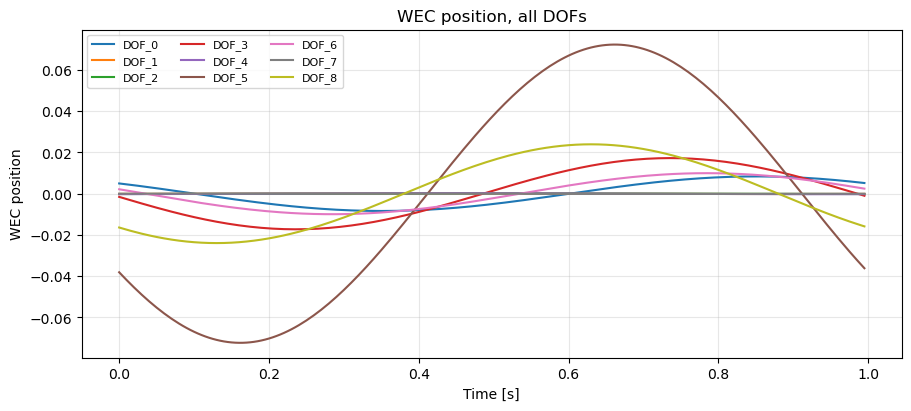

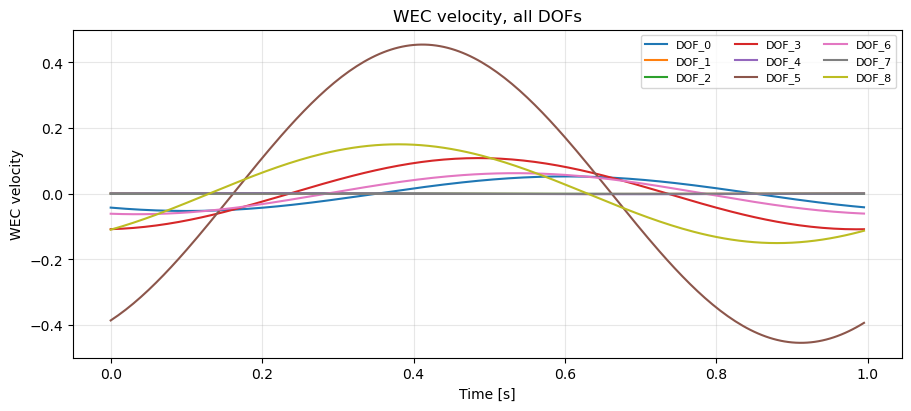

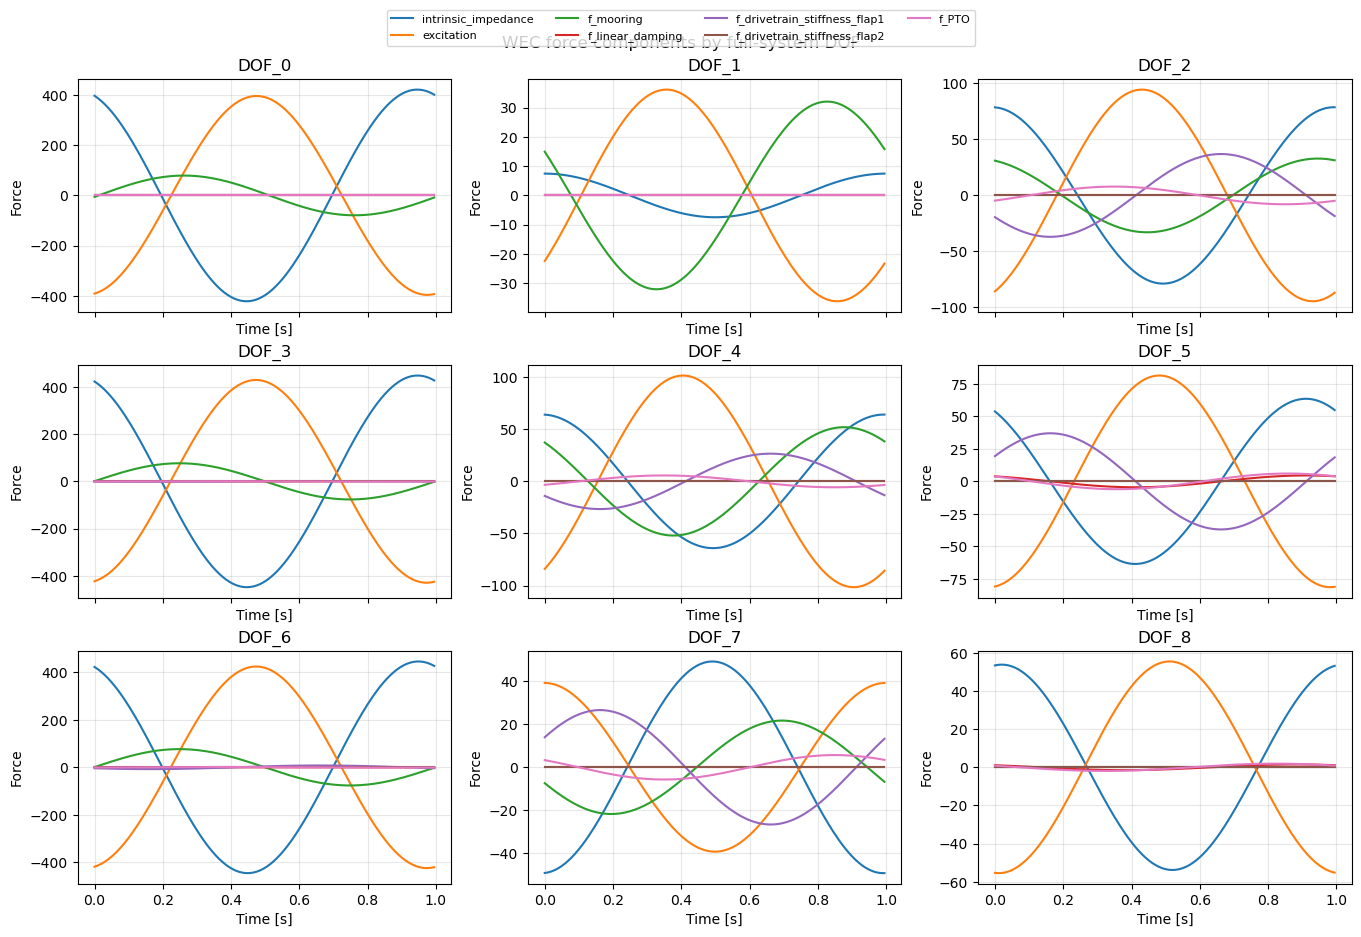

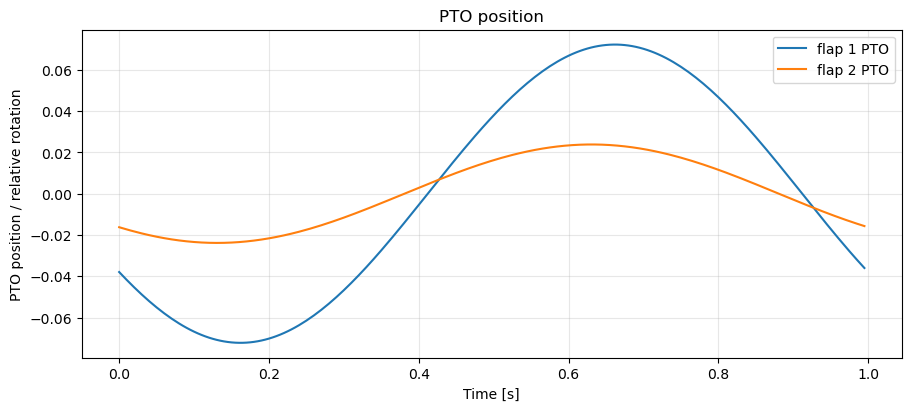

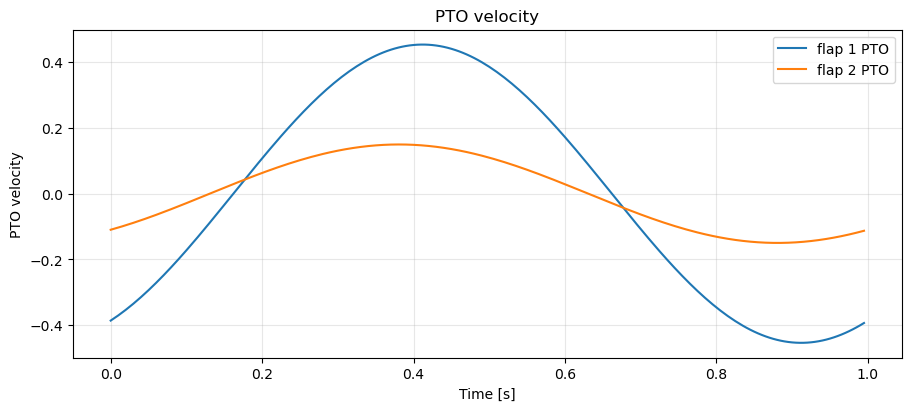

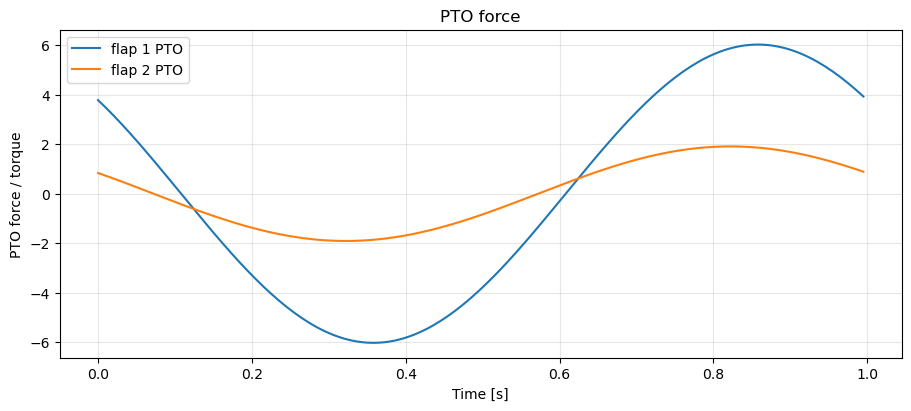

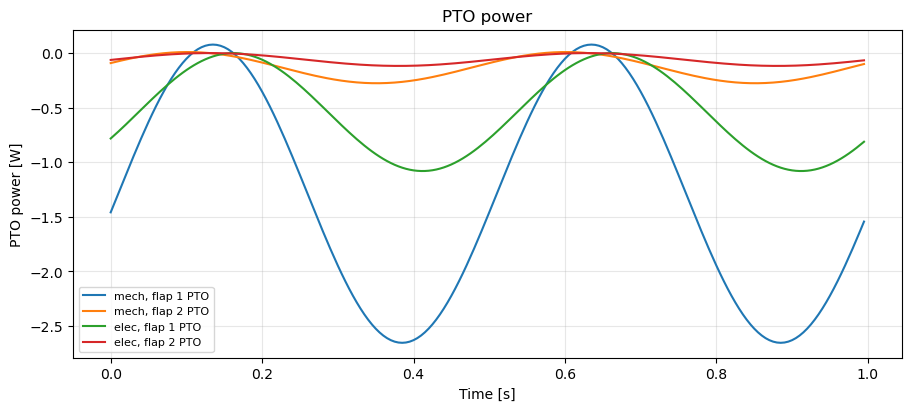

In [37]:
wec_tdom = case["wec_tdom_full"]
pto_tdom = case["pto_tdom"]

plot_wec_pos_all_dofs(wec_tdom)
plot_wec_vel_all_dofs(wec_tdom)
plot_wec_force_types_by_dof(wec_tdom)

plot_pto_pos(pto_tdom)
plot_pto_vel(pto_tdom)
plot_pto_force(pto_tdom)
plot_pto_power(pto_tdom)

plt.show()

In [24]:
mass_sweep_results = xr.Dataset(
    data_vars={
        "avg_power": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "objective": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "generated_power": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "success": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), False, dtype=bool),
        ),
        "flap1_total_mass": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "flap1_cg_height_above_hinge": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "flap1_inertia_cg": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "flap2_total_mass": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "flap2_cg_height_above_hinge": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
        "flap2_inertia_cg": (
            ("wavefreq", "amplitude", "mass_on_top"),
            np.full((len(wavefreq_vec), len(amplitude_vec), len(mass_vec)), np.nan),
        ),
    },
    coords={
        "wavefreq": wavefreq_vec,
        "amplitude": amplitude_vec,
        "mass_on_top": mass_vec,
    },
    attrs={
        "description": "Full-system FOSWEC added-top-mass sweep",
        "controller": "P",
        "f1_factor": f1_factor,
    },
)

full_results = OrderedDict()

record_vars = [
    "opt_power",
    "elec_power_W",
    "mean_elec_power",
    "opt_stiffness",

    "flap1_max_abs_pos",
    "flap2_max_abs_pos",
    "flap1_peak_rotation_utilization",
    "flap2_peak_rotation_utilization",

    "flap1_peak_torque_utilization",
    "flap2_peak_torque_utilization",
    "flap1_rms_torque_utilization",
    "flap2_rms_torque_utilization",
]

for var in record_vars:
    mass_sweep_results[var] = (
        ("wavefreq", "amplitude", "mass_on_top"),
        np.full(
            (len(wavefreq_vec), len(amplitude_vec), len(mass_vec)),
            np.nan,
        ),
    )

In [25]:
for wavefreq in wavefreq_vec:
    wave_period = 1.0 / wavefreq

    for mass_on_top in mass_vec:
        print(
            f"\nRunning setup: wavefreq={wavefreq:.4f} Hz, "
            f"T={wave_period:.3f} s, mass_on_top={mass_on_top:g} kg"
        )

        try:
            study = FOSWECM4EStudyBase(
                wavefreq=float(wavefreq),
                f1=float(wavefreq * f1_factor),
                amplitude=float(amplitude_vec[0]),
                flap1_mass_on_top=float(mass_on_top),
                flap2_mass_on_top=float(mass_on_top),
                **common_study_kwargs,
            )

            study.load_or_run_bem(overwrite=overwrite_bem)
            study.setup_m4e_reduction()

        except Exception:
            logging.exception(
                f"Failed setup for wavefreq={wavefreq:g}, mass={mass_on_top:g}"
            )
            continue

        for amplitude in amplitude_vec:
            loc = dict(
                wavefreq=wavefreq,
                amplitude=amplitude,
                mass_on_top=mass_on_top,
            )

            print(
                f"  Solving A={amplitude:.3f} m, "
                f"mass={mass_on_top:g} kg"
            )

            try:
                study.set_wave_amplitude(
                    amplitude=float(amplitude),
                    seed=wave_seed,
                )

                case = study.solve_controller_case(**controller_kwargs)
                summary = case["summary"]
                cmet = case["constraint_metrics"]
                
                mass_sweep_results["opt_power"].loc[loc] = summary["opt_power"]
                mass_sweep_results["elec_power_W"].loc[loc] = -summary["opt_power"]
                mass_sweep_results["mean_elec_power"].loc[loc] = summary["mean_elec_power"]
                mass_sweep_results["opt_stiffness"].loc[loc] = summary["opt_stiffness"]

                for var in [
                    "flap1_max_abs_pos",
                    "flap2_max_abs_pos",
                    "flap1_peak_rotation_utilization",
                    "flap2_peak_rotation_utilization",
                    "flap1_peak_torque_utilization",
                    "flap2_peak_torque_utilization",
                    "flap1_rms_torque_utilization",
                    "flap2_rms_torque_utilization",
                ]:
                    mass_sweep_results[var].loc[loc] = cmet[var]

                avg_power = summary["avg_power"]
                objective = summary["objective"]

                mass_sweep_results["avg_power"].loc[loc] = avg_power
                mass_sweep_results["objective"].loc[loc] = objective

                # If avg_power already has your desired sign, use this.
                mass_sweep_results["generated_power"].loc[loc] = avg_power

                mass_sweep_results["success"].loc[loc] = True

                mass_sweep_results["flap1_total_mass"].loc[loc] = summary["flap1_total_mass"]
                mass_sweep_results["flap1_cg_height_above_hinge"].loc[loc] = summary["flap1_cg_height_above_hinge"]
                mass_sweep_results["flap1_inertia_cg"].loc[loc] = summary["flap1_inertia_cg"]

                mass_sweep_results["flap2_total_mass"].loc[loc] = summary["flap2_total_mass"]
                mass_sweep_results["flap2_cg_height_above_hinge"].loc[loc] = summary["flap2_cg_height_above_hinge"]
                mass_sweep_results["flap2_inertia_cg"].loc[loc] = summary["flap2_inertia_cg"]

                key = (
                    float(wavefreq),
                    float(amplitude),
                    float(mass_on_top),
                )
                full_results[key] = case

                print(f"    avg_power = {avg_power:.6g}")

            except Exception:
                logging.exception(
                    f"Failed solve: wavefreq={wavefreq:g}, "
                    f"amplitude={amplitude:g}, mass={mass_on_top:g}"
                )
                mass_sweep_results["success"].loc[loc] = False



Running setup: wavefreq=1.0000 Hz, T=1.000 s, mass_on_top=1 kg


INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_61"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio

Problem initialization finished in:		 0.002 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.098 seconds
Symbolic EOM computation finished in:		 0.011 seconds
Compiling EOM expressions finished in:		 0.329 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_61"), lid_mesh=None, dofs={}, name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_67"), lid_mesh=None, dofs={}, name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initiali


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


...

           WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [4 6 7 8
                    9] to a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [4 6 7 8
                    9] to a minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.53e-01, 2.00e+01, 2.39e-03]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.38e-01, 2.00e+01, -1.38e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.22e-01, 2.00e+01, -2.06e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.22e-01, 2.00e+01, -2.06e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.22e-01, 2.00e+01, -2.06e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.22e-01, 2.00e+01, -2.06e-02]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.020586527611204455
            Iterations: 6
            Function evaluations: 7
            Gradient evaluations: 6


[10:02:17] ERROR    Failed solve: wavefreq=1, amplitude=0.05, mass=1                                               
                    Traceback (most recent call last):                                                             
                      File "C:\Users\jtgrasb\AppData\Local\Temp\ipykernel_26924\1878248458.py", line 54, in        
                    <module>                                                                                       
                        mass_sweep_results["opt_stiffness"].loc[loc] = summary["opt_stiffness"]                    
                                                                       ~~~~~~~^^^^^^^^^^^^^^^^^                    
                    KeyError: 'opt_stiffness'

In [26]:
x0_case_names = [
    "zero_k0",
    "zero_k1",
    "zero_k10",
    "zero_k100",
    "rand_wec_small_k10",
    "rand_force_small_k10",
    "rand_wec_force_small_k10",
    "continuation_A005",
]

x0_sweep_results = xr.Dataset(
    data_vars={
        "avg_power": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "objective": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "opt_power": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "elec_power_W": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "mean_elec_power": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "opt_stiffness": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "flap1_peak_rotation_utilization": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "flap2_peak_rotation_utilization": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "flap1_peak_torque_utilization": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "flap2_peak_torque_utilization": (
            ("x0_case",),
            np.full(len(x0_case_names), np.nan),
        ),
        "success": (
            ("x0_case",),
            np.full(len(x0_case_names), False, dtype=bool),
        ),
        "optimizer_success": (
            ("x0_case",),
            np.full(len(x0_case_names), False, dtype=bool),
        ),
    },
    coords={
        "x0_case": x0_case_names,
    },
    attrs={
        "wavefreq": float(1 / 3),
        "amplitude": float(0.25),
        "mass_on_top": float(0.0),
        "controller": "unstructured",
    },
)

x0_full_results = OrderedDict()

controller_kwargs = dict(
    P=False,
    I=False,
    coupled=False,
    unstructured=True,
)

In [27]:
wavefreq = 1 / 2
amplitude_target = 0.25
mass_on_top = 0.0

study = FOSWECM4EStudyBase(
    wavefreq=float(wavefreq),
    f1=float(wavefreq * f1_factor),
    amplitude=float(amplitude_target),
    flap1_mass_on_top=float(mass_on_top),
    flap2_mass_on_top=float(mass_on_top),
    **common_study_kwargs,
)

study.load_or_run_bem(overwrite=overwrite_bem)
study.setup_m4e_reduction()

study.set_wave_amplitude(
    amplitude=float(amplitude_target),
    seed=wave_seed,
)

pto = study.build_pto(**controller_kwargs)

include_drivetrain_stiffness = controller_kwargs.get("unstructured", False) and (
    study.optimize_stiffness or study.fixed_stiffness != 0.0
)

forcing = study.build_additional_forcing(
    include_drivetrain_stiffness=include_drivetrain_stiffness
)

f_add = {
    **forcing,
    "f_PTO": pto.force_on_wec,
}

if study.use_flap_pitch_constraints:
    constraints = study.build_flap_pitch_constraints()
else:
    constraints = None

wec = study.build_wec(f_add, constraints=constraints)

nstate_wec = int(wec.nstate_wec)

nstate_opt, bounds_opt = study.build_controller_bounds(**controller_kwargs)

print("nstate_wec:", nstate_wec)
print("nstate_opt:", nstate_opt)

INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_79"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio

Problem initialization finished in:		 0.001 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.098 seconds
Symbolic EOM computation finished in:		 0.011 seconds
Compiling EOM expressions finished in:		 0.374 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_79"), lid_mesh=None, dofs={}, name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_85"), lid_mesh=None, dofs={}, name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initiali


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_85 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ...}, name="platform+flap1").
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_86 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1+flap2_mesh"), lid_mesh

[10:02:25] WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [9] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [9] to a
                    minimum of  1e-06 N/(m/s)

nstate_wec: 100
nstate_opt: 42


In [28]:
rng = np.random.default_rng(1)

def make_x_opt_0(stiffness=0.0, force_scale=0.0):
    x_opt_0 = np.zeros(nstate_opt)

    if study.optimize_stiffness:
        n_force_states = nstate_opt - 1

        if force_scale != 0.0:
            x_opt_0[:n_force_states] = force_scale * rng.standard_normal(n_force_states)

        x_opt_0[-1] = stiffness

    else:
        if force_scale != 0.0:
            x_opt_0[:] = force_scale * rng.standard_normal(nstate_opt)

    return x_opt_0


def make_x_wec_0(scale=0.0):
    if scale == 0.0:
        return np.zeros(nstate_wec)

    return scale * rng.standard_normal(nstate_wec)

In [29]:
x0_cases = OrderedDict()

x0_cases["zero_k0"] = dict(
    x_wec_0=np.zeros(nstate_wec),
    x_opt_0=make_x_opt_0(stiffness=0.0),
)

x0_cases["zero_k1"] = dict(
    x_wec_0=np.zeros(nstate_wec),
    x_opt_0=make_x_opt_0(stiffness=1.0),
)

x0_cases["zero_k10"] = dict(
    x_wec_0=np.zeros(nstate_wec),
    x_opt_0=make_x_opt_0(stiffness=10.0),
)

x0_cases["zero_k100"] = dict(
    x_wec_0=np.zeros(nstate_wec),
    x_opt_0=make_x_opt_0(stiffness=100.0),
)

x0_cases["rand_wec_small_k10"] = dict(
    x_wec_0=make_x_wec_0(scale=1e-4),
    x_opt_0=make_x_opt_0(stiffness=10.0),
)

x0_cases["rand_force_small_k10"] = dict(
    x_wec_0=np.zeros(nstate_wec),
    x_opt_0=make_x_opt_0(stiffness=10.0, force_scale=1.0),
)

x0_cases["rand_wec_force_small_k10"] = dict(
    x_wec_0=make_x_wec_0(scale=1e-4),
    x_opt_0=make_x_opt_0(stiffness=10.0, force_scale=1.0),
)

In [30]:
try:
    amplitude_seed = 0.05

    study.set_wave_amplitude(
        amplitude=float(amplitude_seed),
        seed=wave_seed,
    )

    seed_case = study.solve_controller_case(**controller_kwargs)

    x_wec_seed = seed_case["summary"]["x_wec"]
    x_opt_seed = seed_case["summary"]["x_opt"]

    x0_cases["continuation_A005"] = dict(
        x_wec_0=(amplitude_target / amplitude_seed) * x_wec_seed,
        x_opt_0=x_opt_seed.copy(),
    )

    print("Continuation seed solve succeeded.")

except Exception:
    logging.exception("Continuation seed solve failed.")

    x0_cases["continuation_A005"] = dict(
        x_wec_0=np.zeros(nstate_wec),
        x_opt_0=make_x_opt_0(stiffness=10.0),
    )

study.set_wave_amplitude(
    amplitude=float(amplitude_target),
    seed=wave_seed,
)

for x0_case_name, init in x0_cases.items():
    print(f"\nRunning x0 case: {x0_case_name}")

    try:
        case = study.solve_controller_case(
            **controller_kwargs,
            x_wec_0_override=init["x_wec_0"],
            x_opt_0_override=init["x_opt_0"],
        )

        summary = case["summary"]
        cmet = case["constraint_metrics"]

        x0_sweep_results["avg_power"].loc[dict(x0_case=x0_case_name)] = summary["avg_power"]
        x0_sweep_results["objective"].loc[dict(x0_case=x0_case_name)] = summary["objective"]
        x0_sweep_results["opt_power"].loc[dict(x0_case=x0_case_name)] = summary["opt_power"]
        x0_sweep_results["elec_power_W"].loc[dict(x0_case=x0_case_name)] = -summary["opt_power"]
        x0_sweep_results["mean_elec_power"].loc[dict(x0_case=x0_case_name)] = summary["mean_elec_power"]
        x0_sweep_results["opt_stiffness"].loc[dict(x0_case=x0_case_name)] = summary["opt_stiffness"]

        for var in [
            "flap1_peak_rotation_utilization",
            "flap2_peak_rotation_utilization",
            "flap1_peak_torque_utilization",
            "flap2_peak_torque_utilization",
        ]:
            x0_sweep_results[var].loc[dict(x0_case=x0_case_name)] = cmet[var]

        x0_sweep_results["success"].loc[dict(x0_case=x0_case_name)] = True

        if hasattr(case["results"][0], "success"):
            x0_sweep_results["optimizer_success"].loc[dict(x0_case=x0_case_name)] = bool(
                case["results"][0].success
            )

        x0_full_results[x0_case_name] = case

        print(
            f"  elec_power_W = {-summary['opt_power']:.6g}, "
            f"opt_stiffness = {summary['opt_stiffness']:.6g}, "
            f"objective = {summary['objective']:.6g}"
        )

    except Exception:
        logging.exception(f"x0 case failed: {x0_case_name}")
        x0_sweep_results["success"].loc[dict(x0_case=x0_case_name)] = False

[10:02:26] WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [9] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [9] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.22e+00, 3.88e-01, -5.31e-04]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.26e+00, 4.07e-01, -4.92e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.31e+00, 5.02e-01, -7.19e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.31e+00, 5.00e-01, -7.19e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.32e+00, 4.98e-01, -7.20e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.32e+00, 4.98e-01, -7.20e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.32e+00, 4.97e-01, -7.20e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.32e+00, 4.96e-01, -7.22e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.34e+00, 7.43e-01, -7.33e-02]
INFO:wecopttool.core:Scaled [ma

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.3811807441318827
            Iterations: 47
            Function evaluations: 49
            Gradient evaluations: 47
Continuation seed solve succeeded.

Running x0 case: zero_k0


[10:02:46] WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [9] to a
                    minimum of  1e-06 N/(m/s)

...


Running x0 case: rand_wec_force_small_k10


[10:04:09] WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [9] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [9] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.


KeyboardInterrupt: 


Best x0 case:
  x0_case = rand_wec_small_k10
  elec_power_W = -11.0738
  opt_stiffness = 29.82984060953646


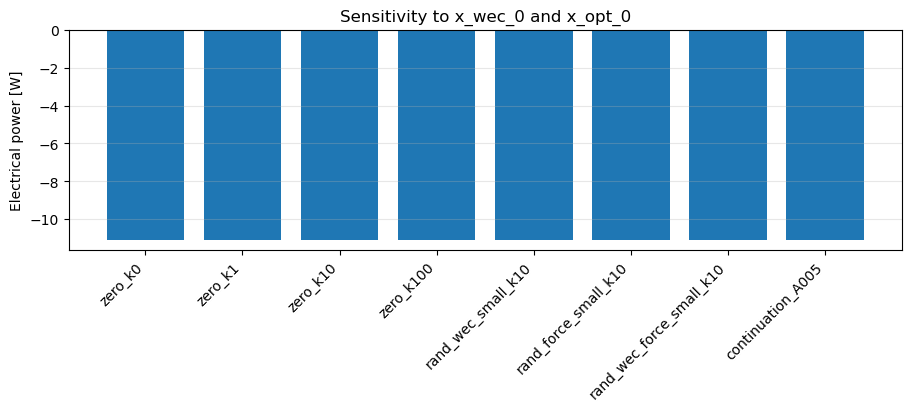

In [ ]:
valid_power = x0_sweep_results["elec_power_W"].where(
    x0_sweep_results["success"]
)

if np.all(np.isnan(valid_power.values)):
    print("No successful x0 cases.")
else:
    best_idx = int(np.nanargmax(valid_power.values))
    best_case = str(x0_sweep_results["x0_case"].values[best_idx])
    best_power = float(valid_power.values[best_idx])

    print("\nBest x0 case:")
    print(f"  x0_case = {best_case}")
    print(f"  elec_power_W = {best_power:.6g}")
    print(
        "  opt_stiffness =",
        float(x0_sweep_results["opt_stiffness"].isel(x0_case=best_idx).values),
    )

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)

ax.bar(
    np.arange(len(x0_sweep_results["x0_case"])),
    x0_sweep_results["elec_power_W"].where(x0_sweep_results["success"]),
)

ax.set_xticks(np.arange(len(x0_sweep_results["x0_case"])))
ax.set_xticklabels(x0_sweep_results["x0_case"].values, rotation=45, ha="right")
ax.set_ylabel("Electrical power [W]")
ax.set_title("Sensitivity to x_wec_0 and x_opt_0")
ax.grid(True, axis="y", alpha=0.3)

plt.show()

In [ ]:
baseline_power = mass_sweep_results["elec_power_W"].sel(mass_on_top=0.0)

mass_sweep_results["power_improvement_pct"] = (
    100.0
    * (
        mass_sweep_results["elec_power_W"] - baseline_power
    )
    / np.abs(baseline_power)
)

KeyError: "not all values found in index 'mass_on_top'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
valid_power = mass_sweep_results["generated_power"].where(
    mass_sweep_results["success"]
)

best_mass = valid_power.idxmax(dim="mass_on_top")
best_power = valid_power.max(dim="mass_on_top")

mass_sweep_results["best_mass_on_top"] = best_mass
mass_sweep_results["best_generated_power"] = best_power

In [ ]:
print("\nBest mass by wave condition:")

for wavefreq in wavefreq_vec:
    for amplitude in amplitude_vec:
        bm = mass_sweep_results["best_mass_on_top"].sel(
            wavefreq=wavefreq,
            amplitude=amplitude,
        ).values

        bp = mass_sweep_results["best_generated_power"].sel(
            wavefreq=wavefreq,
            amplitude=amplitude,
        ).values

        print(
            f"wavefreq={wavefreq:.4f} Hz, "
            f"A={amplitude:.3f} m: "
            f"best_mass={float(bm):g} kg, "
            f"best_power={float(bp):.6g}"
        )


Best mass by wave condition:
wavefreq=0.3333 Hz, A=0.250 m: best_mass=0 kg, best_power=102.843


In [ ]:

def plot_xr_res(ds, qnty, mask_success=True):
    """
    xarray equivalent of plot_df_res(plot_df, qnty).

    Parameters
    ----------
    ds : xr.Dataset
        Dataset with dims: wavefreq, amplitude, mass_on_top.
    qnty : str
        Variable name in ds to plot.
    mask_success : bool
        If True, masks failed cases using ds["success"].
    """

    wavefreq_vals = ds["wavefreq"].values
    amplitude_vals = ds["amplitude"].values

    fig, axs = plt.subplots(
        1,
        len(wavefreq_vals),
        figsize=(2.2 * len(wavefreq_vals), 3.2),
        sharey=True,
        constrained_layout=True,
    )

    axs = np.atleast_1d(axs)

    for ax, wf in zip(axs, wavefreq_vals):
        for amp in amplitude_vals:
            y = ds[qnty].sel(
                wavefreq=wf,
                amplitude=amp,
            )

            if mask_success and "success" in ds:
                y = y.where(
                    ds["success"].sel(
                        wavefreq=wf,
                        amplitude=amp,
                    )
                )

            ax.plot(
                ds["mass_on_top"],
                y,
                marker="o",
                label=f"A={amp:.3f} m",
            )

        ax.set_title(f"wf = {wf:.3f} Hz")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Mass on top [kg]")

    axs[0].set_ylabel(qnty)
    axs[-1].legend(fontsize=8)

    return fig, axs

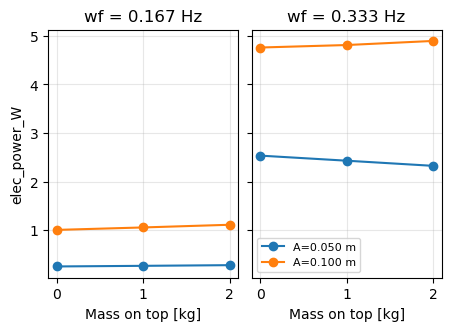

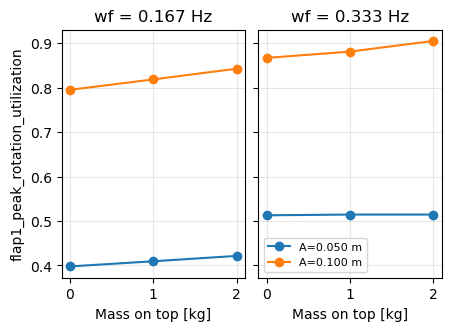

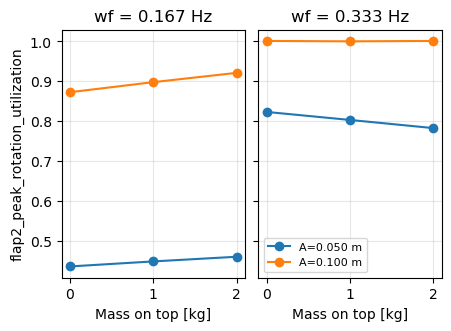

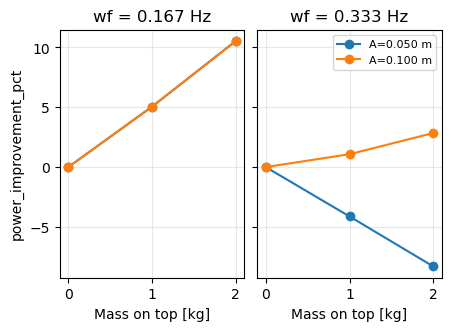

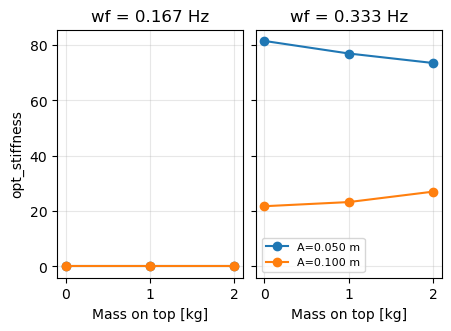

In [ ]:
plot_xr_res(mass_sweep_results, "elec_power_W")
plot_xr_res(mass_sweep_results, "flap1_peak_rotation_utilization")
plot_xr_res(mass_sweep_results, "flap2_peak_rotation_utilization")
plot_xr_res(mass_sweep_results, "power_improvement_pct")
plot_xr_res(mass_sweep_results, "opt_stiffness")
plt.show()

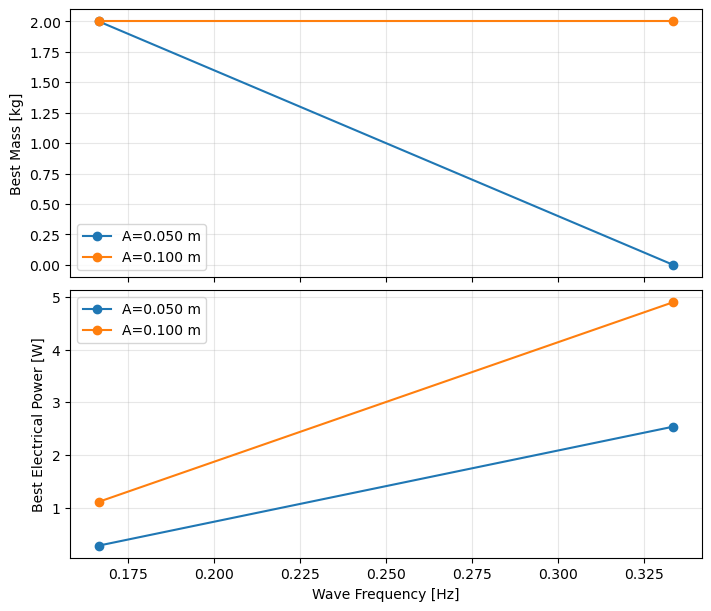

In [ ]:
valid_power = mass_sweep_results["elec_power_W"].where(
    mass_sweep_results["success"]
)

best_mass = valid_power.idxmax(dim="mass_on_top")
best_power = valid_power.max(dim="mass_on_top")

fig, axs = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    sharex=True,
    constrained_layout=True,
)

for amp in mass_sweep_results["amplitude"].values:
    axs[0].plot(
        mass_sweep_results["wavefreq"],
        best_mass.sel(amplitude=amp),
        marker="o",
        label=f"A={amp:.3f} m",
    )

    axs[1].plot(
        mass_sweep_results["wavefreq"],
        best_power.sel(amplitude=amp),
        marker="o",
        label=f"A={amp:.3f} m",
    )

axs[0].set_ylabel("Best Mass [kg]")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].set_xlabel("Wave Frequency [Hz]")
axs[1].set_ylabel("Best Electrical Power [W]")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.show()

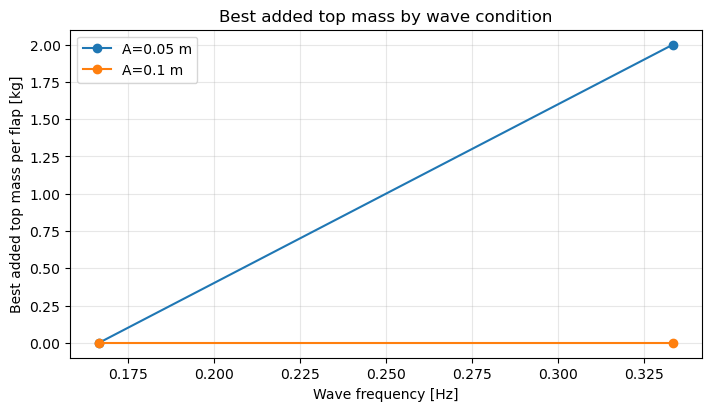

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

for amp in amplitude_vec:
    y = mass_sweep_results["best_mass_on_top"].sel(amplitude=amp)

    ax.plot(
        mass_sweep_results["wavefreq"],
        y,
        marker="o",
        label=f"A={amp:g} m",
    )

ax.set_xlabel("Wave frequency [Hz]")
ax.set_ylabel("Best added top mass per flap [kg]")
ax.set_title("Best added top mass by wave condition")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()